# Model 2C, CatBoost Experiment 02: Raw Taxi-Out and Schedule Margin

This experiment tests whether the feature representation selected by Logistic Regression 2C Experiment 02 also improves CatBoost. It uses the existing `JFK_YEAR_arrivals.csv` dataset and does not create another feature dataset.

Two representations are screened with CatBoost 2C Experiment 01's fixed classifier:

1. the original 31-field log-taxi control;
2. the 31-field raw-taxi allowlist plus model-side `MINUTES_TO_SCHEDULED_ARRIVAL`.

`MINUTES_TO_SCHEDULED_ARRIVAL` equals `CRSElapsedTime - DepDelay - TaxiOut`. CatBoost receives it as one numeric field and learns any nonlinear splits directly. The representation is selected using five expanding 2019 folds. Only the selected representation is tuned and evaluated on 2023. The 2024 dataset is not loaded.

In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4
MAX_ITERATIONS = 1000
EARLY_STOPPING_ROUNDS = 75

CONTROL_ITERATIONS = 406
CONTROL_PARAMETERS = {
    "depth": 6,
    "learning_rate": 0.03,
    "l2_leaf_reg": 10.0,
}

In [2]:
from itertools import product
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


## Load and validate the shared arrival datasets

The experiment uses the same 2019 training rows and 2023 validation rows as the earlier Model 2C experiments.

In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Define the two CatBoost representations

Both variants retain the same 27-field Model 2A base, signed `DepDelay`, and two cyclical actual-takeoff fields. The control uses `LOG_TAXI_OUT_MINUTES`. The candidate replaces it with raw `TaxiOut` and adds the calculated schedule margin as one model-side numeric input.

Each variant therefore admits 31 saved source fields. The candidate has 32 CatBoost inputs after its row-level margin is calculated.

In [4]:
MODEL_2A_CATEGORICAL_FEATURES = [
    "Reporting_Airline",
    "Origin",
]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]

TAKEOFF_TIME_FEATURES = [
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]
CONTROL_NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "LOG_TAXI_OUT_MINUTES",
    *TAKEOFF_TIME_FEATURES,
]
RAW_TAXI_NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "TaxiOut",
    *TAKEOFF_TIME_FEATURES,
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL"

variant_definitions = {
    "control_log_taxi": {
        "source_numeric": CONTROL_NUMERIC_FEATURES,
        "calculated_numeric": [],
    },
    "raw_taxi_schedule_margin": {
        "source_numeric": RAW_TAXI_NUMERIC_FEATURES,
        "calculated_numeric": [CALCULATED_MARGIN],
    },
}

for name, definition in variant_definitions.items():
    source_fields = MODEL_2A_CATEGORICAL_FEATURES + definition["source_numeric"]
    assert len(source_fields) == len(set(source_fields)) == 31, name

required_source_columns = set(MODEL_2A_CATEGORICAL_FEATURES)
for definition in variant_definitions.values():
    required_source_columns.update(definition["source_numeric"])

required_columns = [
    "FlightDate",
    "Dest",
    "CRSDepTime",
    TARGET,
    *sorted(required_source_columns),
]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "ACTUAL_DEP_MINUTE_OF_DAY",
    "ACTUAL_DEP_TIME_SIN",
    "ACTUAL_DEP_TIME_COS",
    "DEPARTED_EARLY",
    "LOG_DEP_DELAY_MINUTES",
    "WheelsOff",
    "ACTUAL_TAKEOFF_MINUTE_OF_DAY",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(required_source_columns)

pd.DataFrame([
    {
        "variant": name,
        "saved_source_fields": 31,
        "taxi_representation": (
            "log" if "LOG_TAXI_OUT_MINUTES" in definition["source_numeric"] else "raw"
        ),
        "calculated_model_inputs": len(definition["calculated_numeric"]),
        "CatBoost_inputs": 31 + len(definition["calculated_numeric"]),
    }
    for name, definition in variant_definitions.items()
]).set_index("variant")

,saved_source_fields,taxi_representation,calculated_model_inputs,CatBoost_inputs
variant,,,,
control_log_taxi,31,log,0,31
raw_taxi_schedule_margin,31,raw,1,32


## Calculate the row-level margin and create chronological folds

The schedule margin uses only values known when the target flight takes off. It is calculated independently for each row and is not saved. CatBoost receives missing numeric values directly; missing categories receive the explicit value `MISSING`.

In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)

    for column in MODEL_2A_CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in required_source_columns.difference(MODEL_2A_CATEGORICAL_FEATURES):
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    frame[CALCULATED_MARGIN] = (
        frame["CRSElapsedTime"] - frame["DepDelay"] - frame["TaxiOut"]
    )
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert train_model_df[CALCULATED_MARGIN].notna().all()
assert validation_model_df[CALCULATED_MARGIN].notna().all()

pd.DataFrame({
    "training": train_model_df[CALCULATED_MARGIN].describe(),
    "external_validation": validation_model_df[CALCULATED_MARGIN].describe(),
})

,training,external_validation
count,"107,354.0000","109,947.0000"
mean,178.5130,165.9134
std,113.4119,117.9957
min,"-1,392.0000","-2,266.0000"
25%,97.0000,94.0000
50%,161.0000,148.0000
75%,288.0000,264.0000
max,578.0000,601.0000


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Screen the representations with the fixed CatBoost 2C-01 classifier

Both representations use 406 trees, depth 6, learning rate 0.03, L2 leaf regularization 10, and no class weighting. Mean average precision from the same five chronological folds selects one representation.

In [7]:
def variant_columns(definition):
    categorical = list(MODEL_2A_CATEGORICAL_FEATURES)
    numeric = [
        *definition["source_numeric"],
        *definition["calculated_numeric"],
    ]
    return categorical, numeric, [*categorical, *numeric]


def make_catboost_model(parameters, iterations, use_best_model):
    return CatBoostClassifier(
        iterations=iterations,
        loss_function="Logloss",
        eval_metric="PRAUC:type=Classic",
        depth=parameters["depth"],
        learning_rate=parameters["learning_rate"],
        l2_leaf_reg=parameters["l2_leaf_reg"],
        auto_class_weights=None,
        random_seed=RANDOM_STATE,
        thread_count=N_JOBS,
        allow_writing_files=False,
        verbose=False,
        use_best_model=use_best_model,
    )


search_start = perf_counter()
screen_rows = []

for variant_name, definition in variant_definitions.items():
    categorical, numeric, columns = variant_columns(definition)
    X_variant = train_model_df[columns].reset_index(drop=True)

    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(
            CONTROL_PARAMETERS,
            iterations=CONTROL_ITERATIONS,
            use_best_model=False,
        )
        model.fit(
            X_variant.iloc[train_idx],
            y_train.iloc[train_idx],
            cat_features=categorical,
            verbose=False,
        )
        probabilities = model.predict_proba(X_variant.iloc[heldout_idx])[:, 1]
        screen_rows.append({
            "variant": variant_name,
            "fold": fold_number,
            "average_precision": average_precision_score(
                y_train.iloc[heldout_idx], probabilities
            ),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })

screen_results = pd.DataFrame(screen_rows)
representation_summary = (
    screen_results
    .groupby("variant", as_index=False)
    .agg(
        screen_mean_average_precision=("average_precision", "mean"),
        screen_std_average_precision=("average_precision", "std"),
        screen_mean_roc_auc=("roc_auc", "mean"),
        screen_mean_brier_score=("brier_score", "mean"),
    )
    .sort_values(
        ["screen_mean_average_precision", "screen_mean_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

selected_variant = str(representation_summary.iloc[0]["variant"])
selected_definition = variant_definitions[selected_variant]
selected_categorical, selected_numeric, selected_columns = variant_columns(
    selected_definition
)

print(f"Selected representation: {selected_variant}")
representation_summary

Selected representation: raw_taxi_schedule_margin


,variant,screen_mean_average_precision,screen_std_average_precision,screen_mean_roc_auc,screen_mean_brier_score
0,raw_taxi_schedule_margin,0.9103,0.0188,0.9552,0.0478
1,control_log_taxi,0.9091,0.0196,0.9544,0.0480


## Tune only the selected representation using 2019

Eight practical candidates compare depths 4 and 6, learning rates 0.03 and 0.10, and L2 leaf regularization 3 and 10. Class weighting remains off because the earlier Model 2C searches selected no class weighting. Each fold uses early stopping on held-out 2019 PRAUC. Mean average precision selects the configuration, and the median fold-best tree count determines the final model size.

In [8]:
parameter_candidates = [
    {
        "depth": depth,
        "learning_rate": rate,
        "l2_leaf_reg": regularization,
    }
    for depth, rate, regularization
    in product([4, 6], [0.03, 0.10], [3, 10])
]

X_train_selected = train_model_df[selected_columns].reset_index(drop=True)
X_validation_selected = validation_model_df[selected_columns].reset_index(drop=True)
tuning_rows = []

for candidate_number, parameters in enumerate(parameter_candidates, start=1):
    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(
            parameters,
            iterations=MAX_ITERATIONS,
            use_best_model=True,
        )
        model.fit(
            X_train_selected.iloc[train_idx],
            y_train.iloc[train_idx],
            cat_features=selected_categorical,
            eval_set=(
                X_train_selected.iloc[heldout_idx],
                y_train.iloc[heldout_idx],
            ),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose=False,
        )
        probabilities = model.predict_proba(
            X_train_selected.iloc[heldout_idx]
        )[:, 1]
        tuning_rows.append({
            "candidate": candidate_number,
            "fold": fold_number,
            **parameters,
            "best_iteration": model.get_best_iteration() + 1,
            "average_precision": average_precision_score(
                y_train.iloc[heldout_idx], probabilities
            ),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })
    print(f"Completed candidate {candidate_number}/{len(parameter_candidates)}")

tuning_fold_results = pd.DataFrame(tuning_rows)
candidate_results = (
    tuning_fold_results
    .groupby(
        ["candidate", "depth", "learning_rate", "l2_leaf_reg"],
        as_index=False,
    )
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
        median_best_iteration=("best_iteration", "median"),
        min_best_iteration=("best_iteration", "min"),
        max_best_iteration=("best_iteration", "max"),
    )
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False)
)

best_candidate = candidate_results.iloc[0]
selected_parameters = {
    "depth": int(best_candidate["depth"]),
    "learning_rate": float(best_candidate["learning_rate"]),
    "l2_leaf_reg": float(best_candidate["l2_leaf_reg"]),
}
selected_iterations = max(1, int(best_candidate["median_best_iteration"]))
search_seconds = perf_counter() - search_start

print(f"Screen and tuning completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {best_candidate['mean_average_precision']:.4f}")
print(f"Selected parameters: {selected_parameters}")
print(f"Selected iteration count: {selected_iterations}")
candidate_results

Completed candidate 1/8


Completed candidate 2/8


Completed candidate 3/8


Completed candidate 4/8


Completed candidate 5/8


Completed candidate 6/8


Completed candidate 7/8


Completed candidate 8/8
Screen and tuning completed in 332.5 seconds
Best mean temporal-validation AP: 0.9112
Selected parameters: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 10.0}
Selected iteration count: 364


,candidate,depth,learning_rate,l2_leaf_reg,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_iteration,min_best_iteration,max_best_iteration
5,6,6,0.0300,10,0.9112,0.0184,0.9564,0.0479,364.0000,141,997
4,5,6,0.0300,3,0.9110,0.0189,0.9562,0.0479,484.0000,151,996
2,3,4,0.1000,3,0.9109,0.0177,0.9560,0.0478,261.0000,32,517
7,8,6,0.1000,10,0.9109,0.0175,0.9560,0.0479,170.0000,50,361
0,1,4,0.0300,3,0.9107,0.0186,0.9558,0.0478,684.0000,188,1000
3,4,4,0.1000,10,0.9103,0.0187,0.9558,0.0482,265.0000,52,492
1,2,4,0.0300,10,0.9101,0.0186,0.9554,0.0481,547.0000,136,1000
6,7,6,0.1000,3,0.9100,0.0188,0.9551,0.0480,91.0000,63,292


## Select the operating threshold using 2019 only

The selected representation and fixed tree count are refitted once per chronological fold. Thresholds from 0.05 through 0.50 are ranked by F1 on held-out 2019 probabilities, with balanced accuracy and precision as tie-breakers.

In [9]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = make_catboost_model(
        selected_parameters,
        iterations=selected_iterations,
        use_best_model=False,
    )
    fold_model.fit(
        X_train_selected.iloc[train_idx],
        y_train.iloc[train_idx],
        cat_features=selected_categorical,
        verbose=False,
    )
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train_selected.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).head(10)

Threshold-selection rows: 89,578
Training-only selected threshold: 0.36


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
31,0.3600,0.9390,0.8833,0.8958,0.7899,0.8395,0.8045,0.9559,0.9139,0.0478
32,0.3700,0.9392,0.8822,0.8995,0.7865,0.8392,0.8047,0.9559,0.9139,0.0478
30,0.3500,0.9387,0.8840,0.8920,0.7922,0.8392,0.8036,0.9559,0.9139,0.0478
33,0.3800,0.9393,0.8812,0.9028,0.7837,0.8390,0.8049,0.9559,0.9139,0.0478
29,0.3400,0.9382,0.8847,0.8874,0.7950,0.8386,0.8024,0.9559,0.9139,0.0478
34,0.3900,0.9393,0.8801,0.9057,0.7807,0.8386,0.8048,0.9559,0.9139,0.0478
28,0.3300,0.9379,0.8856,0.8832,0.7979,0.8384,0.8017,0.9559,0.9139,0.0478
27,0.3200,0.9376,0.8864,0.8795,0.8006,0.8382,0.8010,0.9559,0.9139,0.0478
35,0.4000,0.9393,0.8791,0.9083,0.7780,0.8381,0.8047,0.9559,0.9139,0.0478
26,0.3100,0.9373,0.8874,0.8752,0.8038,0.8380,0.8003,0.9559,0.9139,0.0478


## Refit the selected design on 2019 and evaluate 2023

Only the representation selected from 2019 is evaluated on 2023. CatBoost 2C Experiment 01 and Logistic Regression 2C Experiment 02 are included as documented fixed comparisons and are not refitted here.

In [10]:
final_fit_start = perf_counter()
best_catboost_model = make_catboost_model(
    selected_parameters,
    iterations=selected_iterations,
    use_best_model=False,
)
best_catboost_model.fit(
    X_train_selected,
    y_train,
    cat_features=selected_categorical,
    verbose=False,
)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_catboost_model.predict_proba(
    X_validation_selected
)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "CatBoost 2C-01 (documented)",
        "threshold": 0.37,
        "accuracy": 0.9188,
        "balanced_accuracy": 0.8704,
        "precision": 0.8810,
        "recall": 0.7750,
        "f1": 0.8246,
        "mcc": 0.7747,
        "roc_auc": 0.9461,
        "average_precision": 0.9080,
        "brier_score": 0.0626,
    },
    {
        "model": "Logistic Regression 2C-02 (documented)",
        "threshold": 0.45,
        "accuracy": 0.9239,
        "balanced_accuracy": 0.8712,
        "precision": 0.9098,
        "recall": 0.7672,
        "f1": 0.8324,
        "mcc": 0.7885,
        "roc_auc": 0.9491,
        "average_precision": 0.9145,
        "brier_score": 0.0594,
    },
    {
        "model": "CatBoost 2C-02 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "CatBoost 2C-02 (training-selected)",
        **evaluate_probabilities(
            y_validation,
            validation_probabilities,
            selected_threshold,
        ),
    },
]).set_index("model")

print(
    f"Final all-2019 fit: {final_fit_seconds:,.1f} seconds; "
    f"trees: {best_catboost_model.tree_count_:,}"
)
evaluation_results

Final all-2019 fit: 9.2 seconds; trees: 364


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
CatBoost 2C-01 (documented),0.3700,0.9188,0.8704,0.8810,0.7750,0.8246,0.7747,0.9461,0.9080,0.0626
Logistic Regression 2C-02 (documented),0.4500,0.9239,0.8712,0.9098,0.7672,0.8324,0.7885,0.9491,0.9145,0.0594
CatBoost 2C-02 (default),0.5000,0.9204,0.8591,0.9227,0.7385,0.8204,0.7779,0.9466,0.9092,0.0620
CatBoost 2C-02 (training-selected),0.3600,0.9193,0.8713,0.8817,0.7767,0.8259,0.7763,0.9466,0.9092,0.0620


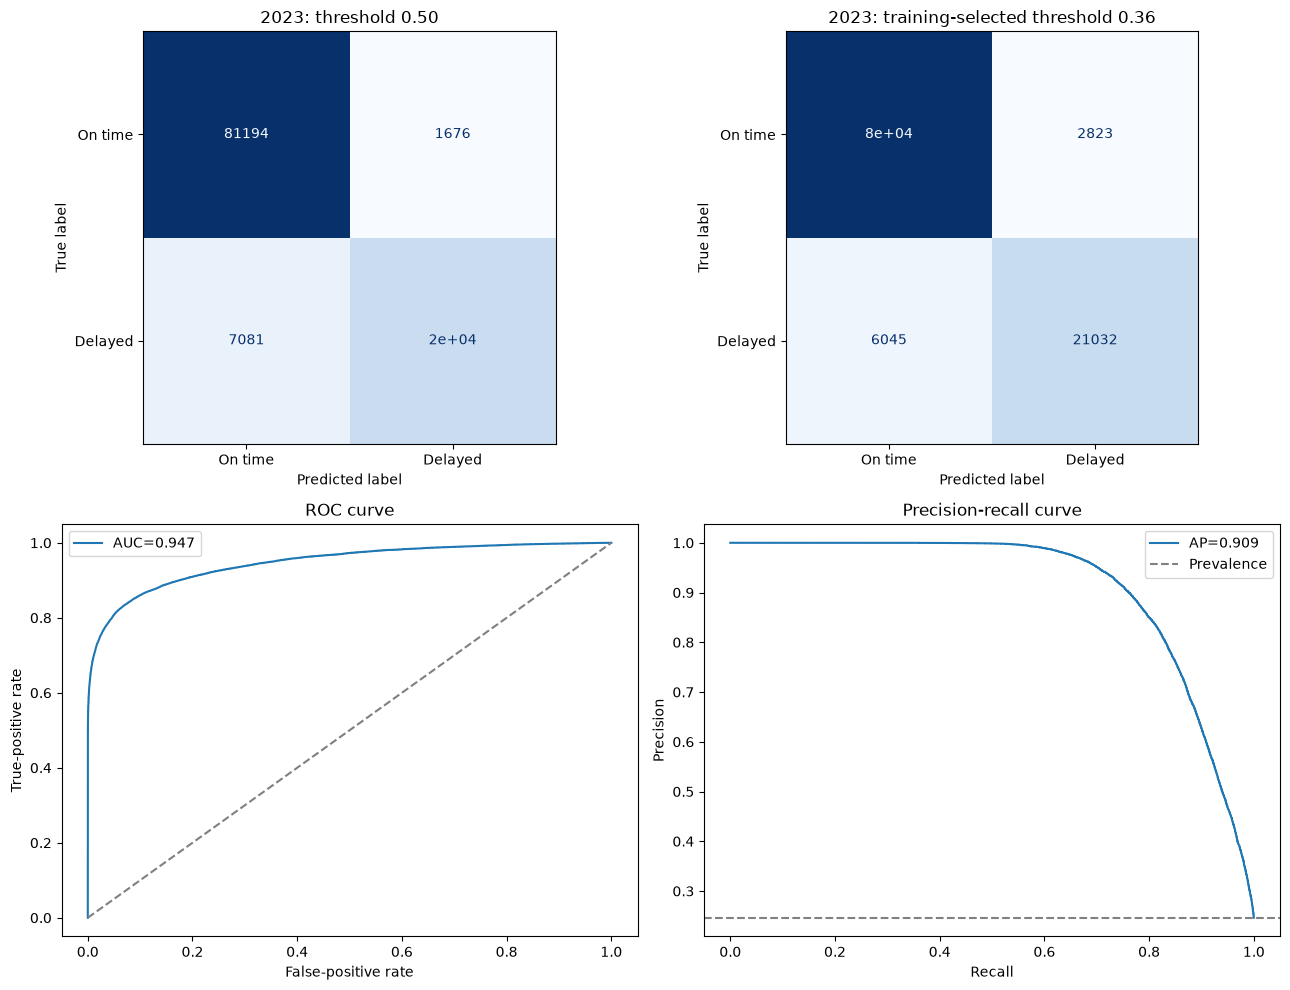

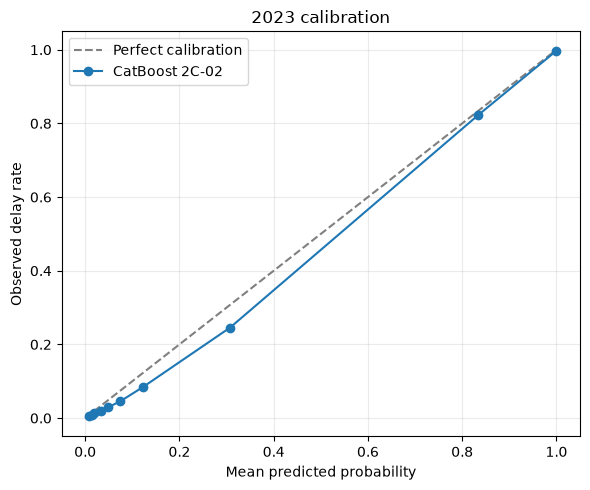

In [11]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023: training-selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(), linestyle="--", color="gray", label="Prevalence"
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="CatBoost 2C-02")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect feature importance and publishable values

CatBoost importance describes predictive contribution within this fitted model. It does not establish that a field caused an arrival delay.

In [12]:
feature_importance = (
    pd.DataFrame({
        "feature": selected_columns,
        "importance": best_catboost_model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance)

default = evaluation_results.loc["CatBoost 2C-02 (default)"]
selected = evaluation_results.loc["CatBoost 2C-02 (training-selected)"]
publishable_summary = pd.Series({
    "CatBoost version": catboost.__version__,
    "selected representation": selected_variant,
    "saved source fields": 31,
    "calculated model-side fields": len(selected_definition["calculated_numeric"]),
    "CatBoost inputs": len(selected_columns),
    "selected depth": selected_parameters["depth"],
    "selected learning rate": selected_parameters["learning_rate"],
    "selected L2 leaf regularization": selected_parameters["l2_leaf_reg"],
    "selected class weighting": "None",
    "selected trees": selected_iterations,
    "training CV AP": best_candidate["mean_average_precision"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="CatBoost 2C Experiment 02 Appendix F values")
publishable_summary.to_frame()

,feature,importance
0,DepDelay,43.7268
1,TaxiOut,16.0609
2,MINUTES_TO_SCHEDULED_ARRIVAL,9.2521
3,DAY_OF_YEAR_COS,5.3808
4,SCHEDULED_SPEED_PROXY,4.6728
5,DAY_OF_YEAR_SIN,4.1501
6,LOG_DISTANCE,2.7168
7,Reporting_Airline,1.9816
8,SCHED_ARR_TIME_SIN,1.8997
9,CRSElapsedTime,1.4284


,CatBoost 2C Experiment 02 Appendix F values
CatBoost version,1.2.10
selected representation,raw_taxi_schedule_margin
saved source fields,31
calculated model-side fields,1
CatBoost inputs,32
selected depth,6
selected learning rate,0.0300
selected L2 leaf regularization,10.0000
selected class weighting,None
selected trees,364


## Interpretation checklist

1. Does the raw-taxi schedule-margin representation improve mean 2019 temporal average precision under the fixed CatBoost 2C-01 classifier?
2. Does the tuned selected design improve 2023 average precision, ROC AUC, Brier score, F1, or MCC over CatBoost 2C-01?
3. Does CatBoost improve on Logistic Regression 2C-02 when both use the schedule-margin hypothesis?
4. Is `MINUTES_TO_SCHEDULED_ARRIVAL` important in the fitted CatBoost model?
5. Keep the existing saved arrival feature dataset unchanged.
6. Keep the 2024 dataset untouched until the final classifier and threshold are selected.